In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
np.random.seed(42)

In [10]:
url = "https://raw.githubusercontent.com/d-eremina/datasets/master/DailyDelhiClimateTrain.csv"
df = pd.read_csv(url)

In [11]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.drop_duplicates().dropna(subset=["date"]).sort_values("date").reset_index(drop=True)

# meanpressure has a few known garbage outlier values in this dataset — clip to a
# physically sensible range for meteorological pressure.
df["meanpressure"] = df["meanpressure"].clip(950, 1050)

df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


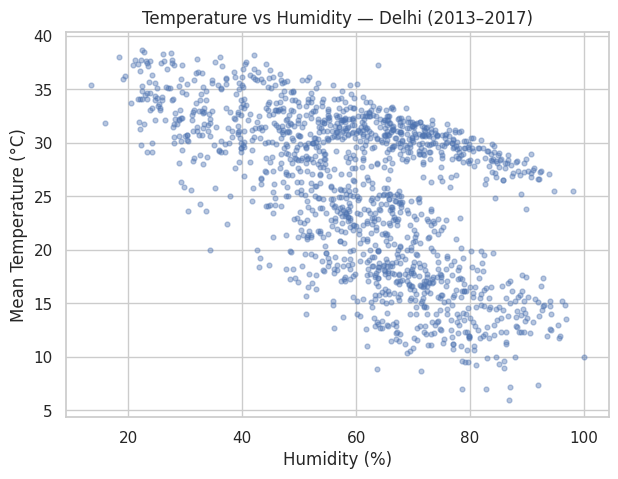

Scatter    : shows how humidity and temperature relate (broad negative trend).


In [12]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df["humidity"], df["meantemp"], alpha=0.4, s=12)
ax.set(xlabel="Humidity (%)", ylabel="Mean Temperature (°C)",
       title="Temperature vs Humidity — Delhi (2013–2017)")
plt.show()

print("Scatter    : shows how humidity and temperature relate (broad negative trend).")

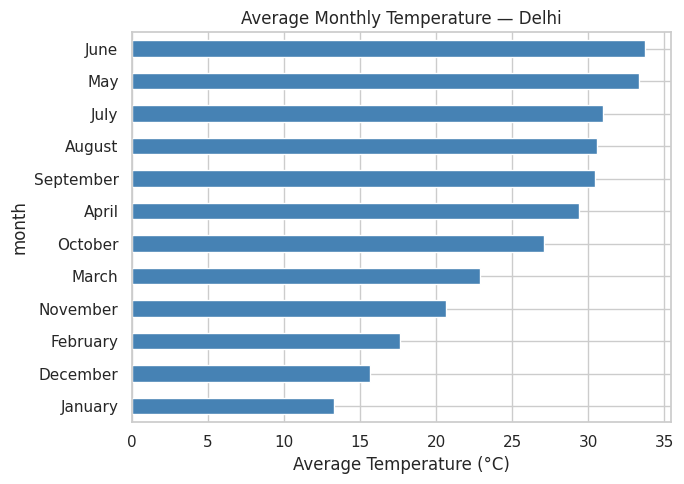

Bar chart  : ranks months by average temperature (peak in summer months).


In [13]:
monthly_avg = df.assign(month=df["date"].dt.month_name()).groupby("month")["meantemp"].mean()
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]
monthly_avg = monthly_avg.reindex(month_order)

monthly_avg.sort_values().plot(kind="barh", figsize=(7, 5), color="steelblue")
plt.xlabel("Average Temperature (°C)")
plt.title("Average Monthly Temperature — Delhi")
plt.tight_layout()
plt.show()

print("Bar chart  : ranks months by average temperature (peak in summer months).")

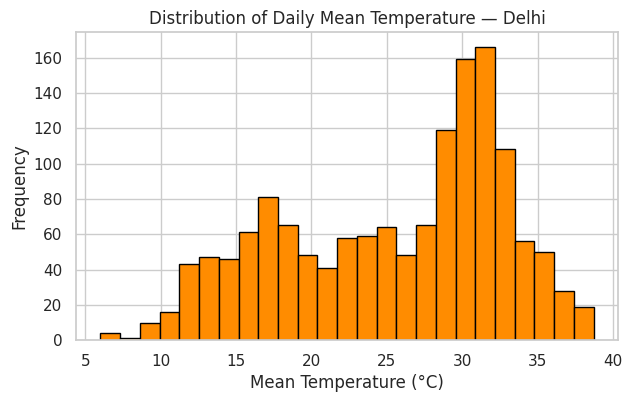

Histogram  : shows temperature is bimodal-ish across summer/winter seasons.


In [14]:
plt.figure(figsize=(7, 4))
plt.hist(df["meantemp"], bins=25, color="darkorange", edgecolor="black")
plt.xlabel("Mean Temperature (°C)")
plt.ylabel("Frequency")
plt.title("Distribution of Daily Mean Temperature — Delhi")
plt.show()

print("Histogram  : shows temperature is bimodal-ish across summer/winter seasons.")

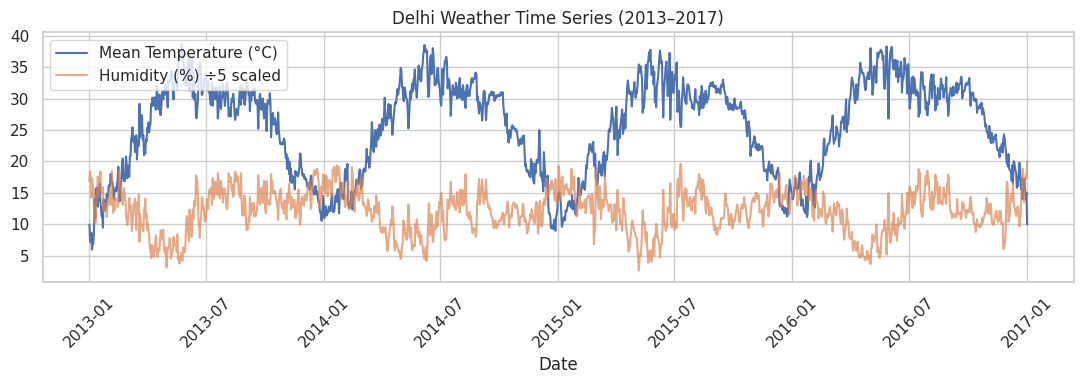

Time series: reveals a clear yearly seasonal cycle across 2013-2017.


In [15]:
plt.figure(figsize=(11, 4))
plt.plot(df["date"], df["meantemp"], label="Mean Temperature (°C)")
plt.plot(df["date"], df["humidity"] / 5, label="Humidity (%) ÷5 scaled", alpha=0.7)
plt.xlabel("Date")
plt.title("Delhi Weather Time Series (2013–2017)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Time series: reveals a clear yearly seasonal cycle across 2013-2017.")

In [16]:
print("Scatter    : shows how humidity and temperature relate (broad negative trend).")
print("Bar chart  : ranks months by average temperature (peak in summer months).")
print("Histogram  : shows temperature is bimodal-ish across summer/winter seasons.")
print("Time series: reveals a clear yearly seasonal cycle across 2013-2017.")

# =============================================================================
# Record Sheet (fill in for your lab report)
# -----------------------------------------------------------------------------
# Dataset used            : Daily Delhi Climate (Kaggle - sumanthvrao), 2013-2017
# Number of observations  : ~1462 (before cleaning)
# Key variables            : meantemp, humidity, date
# Main visualization       : time-series line graph (Cell 7)
# Main finding             : strong seasonal cycle; humidity broadly inversely
#                             related to temperature
# Limitations               : single city; humidity/temperature scaled for
#                             co-plotting in Cell 7, not directly comparable in units
# =============================================================================


Scatter    : shows how humidity and temperature relate (broad negative trend).
Bar chart  : ranks months by average temperature (peak in summer months).
Histogram  : shows temperature is bimodal-ish across summer/winter seasons.
Time series: reveals a clear yearly seasonal cycle across 2013-2017.
